# 🚀 Lab 50: Predictive Forecasting for Logistics and Finance

## 🎯 Learning Objectives
By the end of this lab, you will be able to:
* Understand the fundamentals of time series forecasting for business applications.
* Implement **SARIMA** models for traffic flow prediction.
* Use **Prophet** for robust time series forecasting in logistics and finance.
* Load and process historical stock market data using `yfinance`.
* Evaluate model performance using **MAPE**, **RMSE**, and **MAE**.
* Create professional visualizations and a summary dashboard.

## 🧰 Prerequisites
* Basic Python programming and `pandas` familiarity.
* Basic understanding of statistics and time series concepts.
* Internet access (for `yfinance`, though a fallback is provided).

## ⚙️ Environment Setup
### 👶 ELI10: What are we doing?
Before we can predict the future, we need to gather our tools. Think of this like setting up a kitchen before cooking; we need specific pans (libraries) for data handling, plotting, and specialized forecasting math.

**Why?** Libraries like `prophet` and `statsmodels` do the heavy lifting for complex math, while `yfinance` lets us peek at real-world stock market history.

**Result:** A clean environment ready to process data.

In [1]:
# Install required packages for forecasting and financial data
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels prophet yfinance

In [2]:
# Import essential libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8")

# Time Series Modeling
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# Finance and Evaluation
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import datetime, timedelta

# Seed for reproducibility
np.random.seed(42)
print("✅ Environment ready! All libraries imported successfully.")

✅ Environment ready! All libraries imported successfully.


## 📥 Data Preparation
### 👶 ELI10: Creating our playground
We need data to practice on. We will create "fake" traffic data that looks real (with morning rushes and weekend lulls) and try to fetch real Apple stock data.

**Why?** In the real world, data is messy. Generating our own traffic data ensures we know the ground truth, while using real stock data prepares us for the unpredictability of markets.

**Result:** Two clean DataFrames ready for analysis.

In [3]:
def generate_traffic_data():
    """Generates 2 years of hourly traffic data with realistic seasonal patterns."""
    dates = pd.date_range(start="2022-01-01 00:00:00", end="2023-12-31 23:00:00", freq="h")

    # Patterns: 24h cycle, 7d cycle, 365d cycle
    base_pattern = 100 + 50 * np.sin(2 * np.pi * np.arange(len(dates)) / 24)
    weekly_pattern = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / (24 * 7))
    seasonal_pattern = 30 * np.sin(2 * np.pi * np.arange(len(dates)) / (24 * 365))
    noise = np.random.normal(0, 10, len(dates))

    traffic_flow = np.maximum(base_pattern + weekly_pattern + seasonal_pattern + noise, 10)
    return pd.DataFrame({"datetime": dates, "traffic_flow": traffic_flow})

traffic_data = generate_traffic_data()
display(traffic_data.head())
print(f"Traffic Shape: {traffic_data.shape}")

,datetime,traffic_flow
0,2022-01-01 00:00:00,104.967142
1,2022-01-01 01:00:00,112.327651
2,2022-01-01 02:00:00,133.014523
3,2022-01-01 03:00:00,152.889480
4,2022-01-01 04:00:00,144.026653


Traffic Shape: (17520, 2)


In [4]:
def load_stock_data(symbol="AAPL", period="2y"):
    """Loads stock data from Yahoo Finance with a synthetic fallback if offline."""
    try:
        stock = yf.download(symbol, period=period, interval="1d", auto_adjust=True, progress=False)
        if stock.empty: raise ValueError("Empty data")
        stock = stock.reset_index()
        # Handle MultiIndex and rename
        stock.columns = [col[0] if isinstance(col, tuple) else col for col in stock.columns]
        df = stock[['Date', 'Close', 'Volume']].copy()
        df.columns = ["date", "price", "volume"]
        print(f"Successfully loaded {symbol} from Yahoo Finance.")
        return df
    except Exception as e:
        print(f"Fallback triggered: {e}")
        dates = pd.date_range(end=pd.Timestamp.today(), periods=504, freq="B")
        price = 150 + np.cumsum(np.random.normal(0.1, 2, 504))
        return pd.DataFrame({"date": dates, "price": price, "volume": np.random.randint(1e6, 1e7, 504)})

stock_data = load_stock_data()
display(stock_data.head())

Successfully loaded AAPL from Yahoo Finance.


,date,price,volume
0,2024-04-18,165.533493,43122900
1,2024-04-19,163.511917,68149400
2,2024-04-22,164.344299,48116400
3,2024-04-23,165.394775,49537800
4,2024-04-24,167.495651,48251800


## 🚦 Traffic Data Forecasting with SARIMA
### 👶 ELI10: Teaching the computer about cycles
SARIMA is like a smart observer that notices: "Hey, traffic is always heavy at 8 AM!" and "It's always quiet on Sundays!"

**Why?** Logistic companies need to know when to put more trucks on the road. We use SARIMA because it is excellent at handling data that repeats in cycles.

**Result:** A prediction that tries to match future traffic based on past patterns.

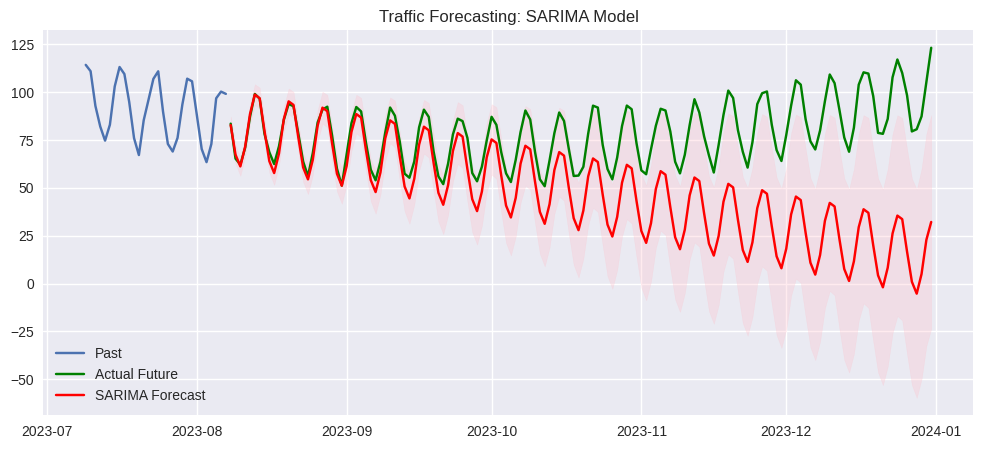

In [5]:
def prepare_sarima_data(df):
    """Resample to daily mean to simplify the SARIMA process for this lab."""
    return df.set_index("datetime")["traffic_flow"].resample("D").mean()

daily_traffic = prepare_sarima_data(traffic_data)

# Split 80/20
split_idx = int(len(daily_traffic) * 0.8)
train_traffic, test_traffic = daily_traffic[:split_idx], daily_traffic[split_idx:]

# Fit SARIMA (Seasonal AutoRegressive Integrated Moving Average)
model = SARIMAX(train_traffic, order=(1,1,1), seasonal_order=(1,1,1,7), enforce_stationarity=False)
sarima_res = model.fit(disp=False)

# Forecast
forecast_obj = sarima_res.get_forecast(steps=len(test_traffic))
sarima_forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(train_traffic.index[-30:], train_traffic[-30:], label="Past")
plt.plot(test_traffic.index, test_traffic, label="Actual Future", color="green")
plt.plot(test_traffic.index, sarima_forecast, label="SARIMA Forecast", color="red")
plt.fill_between(test_traffic.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title("Traffic Forecasting: SARIMA Model")
plt.legend()
plt.show()

## 📈 Traffic Data Forecasting with Prophet
### 👶 ELI10: The Automated Forecaster
Prophet is a tool made by Facebook that is very good at handling missing data and big changes (like holidays). It's easier to use than SARIMA because it handles more things automatically.

**Why?** It's robust. If some data is missing or there's a weird spike, Prophet usually doesn't crash or give a crazy answer.

**Result:** A flexible forecast for traffic flow.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


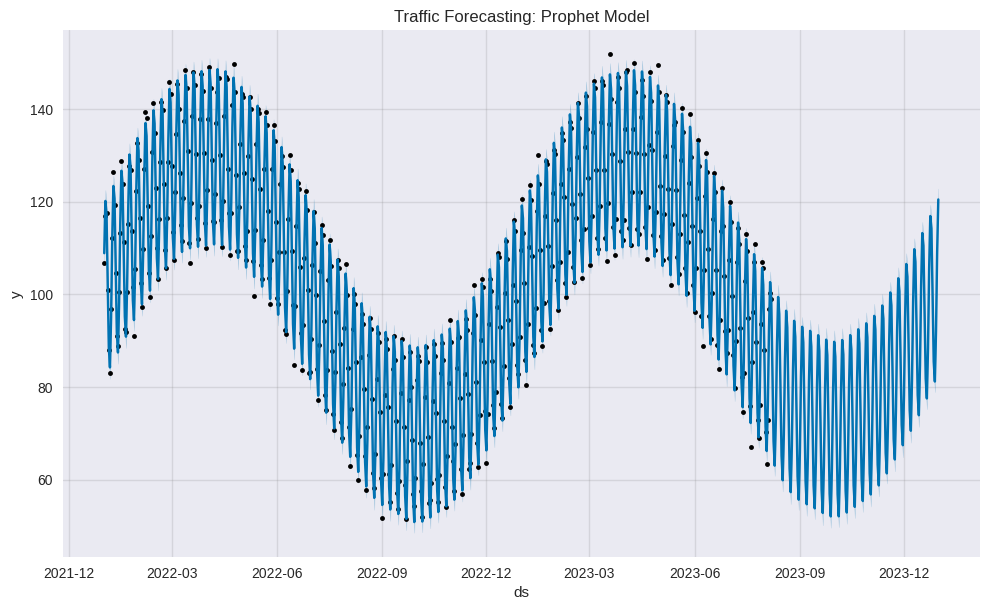

In [6]:
# Prophet requires specific column names: 'ds' (datestamp) and 'y' (value)
prophet_df = daily_traffic.reset_index().rename(columns={'datetime': 'ds', 'traffic_flow': 'y'})
train_p, test_p = prophet_df[:split_idx], prophet_df[split_idx:]

m_traffic = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m_traffic.fit(train_p)

# Predict
future_traffic = m_traffic.make_future_dataframe(periods=len(test_p))
forecast_traffic = m_traffic.predict(future_traffic)

# Plot
m_traffic.plot(forecast_traffic)
plt.title("Traffic Forecasting: Prophet Model")
plt.show()

## 💹 Stock Price Forecasting with Prophet
### 👶 ELI10: Predicting the Market
Stocks are much harder to predict than traffic because traffic is governed by physics and human habits, while stocks are governed by news and emotions.

**Why?** Finance teams use these models as a baseline to understand the "trend" of a stock, even if they can't predict the exact price tomorrow.

**Result:** A directional forecast of stock prices.

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


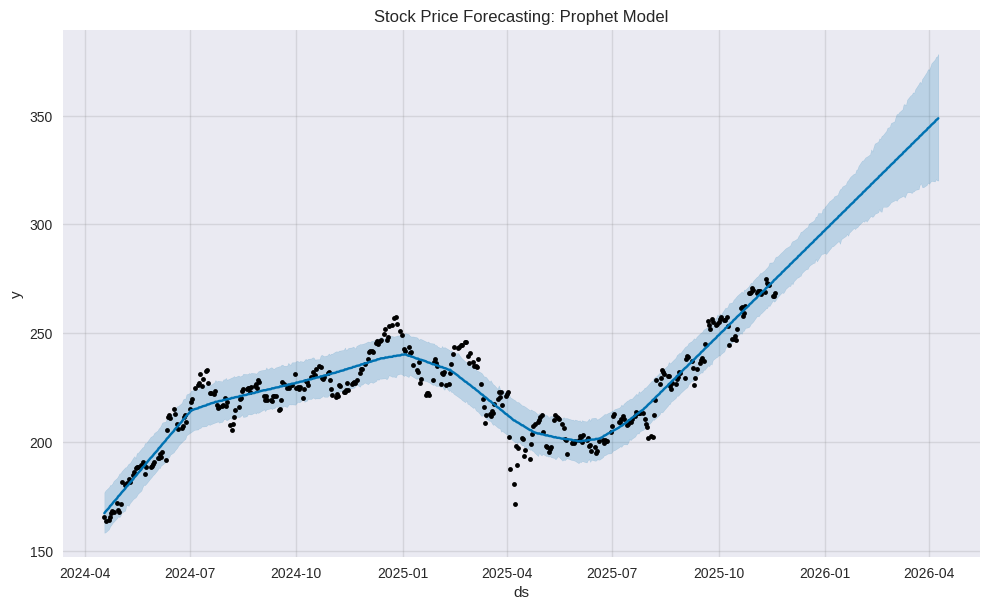

In [7]:
stock_p_df = stock_data.rename(columns={'date': 'ds', 'price': 'y'})
s_split = int(len(stock_p_df) * 0.8)
s_train, s_test = stock_p_df[:s_split], stock_p_df[s_split:]

m_stock = Prophet(daily_seasonality=False, changepoint_prior_scale=0.05)
m_stock.fit(s_train)

future_stock = m_stock.make_future_dataframe(periods=len(s_test), freq='B')
forecast_stock = m_stock.predict(future_stock)

m_stock.plot(forecast_stock)
plt.title("Stock Price Forecasting: Prophet Model")
plt.show()

## 📊 Results Dashboard
### 👶 ELI10: The Report Card
Now we look at our scores. We use MAPE (Percentage Error) to see how far off we were. 5% error is great; 50% error is bad!

**Why?** Executives don't want to see code; they want to see a summary of which model worked best.

**Result:** A 3x2 grid of charts showing our wins and losses.

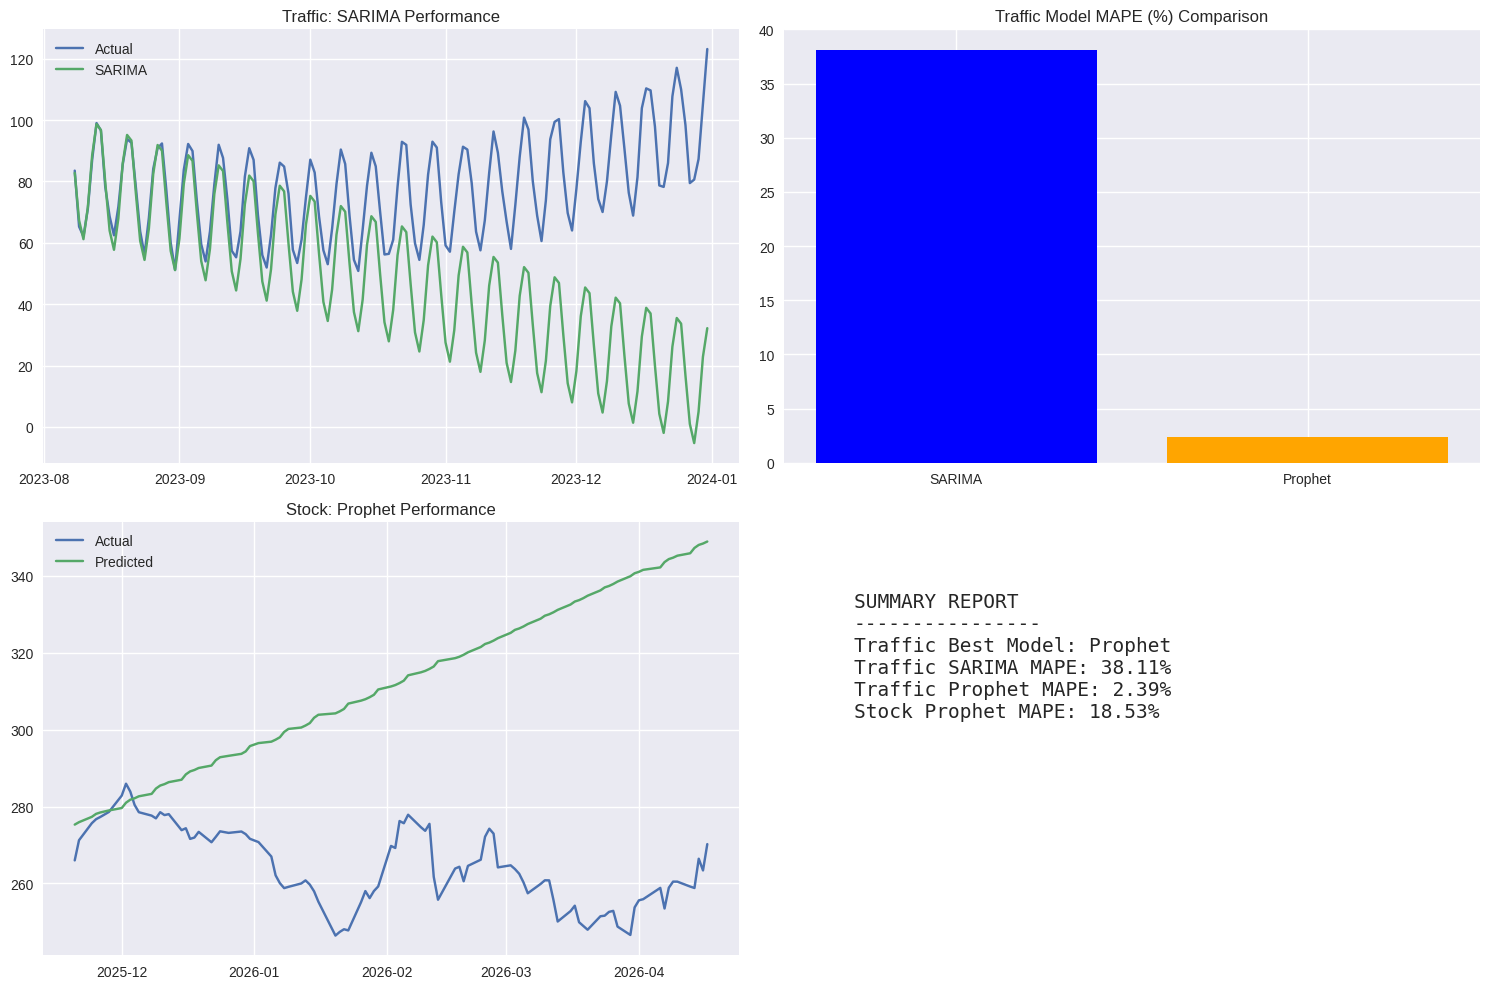

In [8]:
def evaluate(actual, pred):
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    rmse = np.sqrt(mean_squared_error(actual, pred))
    return mape, rmse

# Calc metrics
s_mape, s_rmse = evaluate(test_traffic.values, sarima_forecast.values)
p_mape, p_rmse = evaluate(test_p['y'].values, forecast_traffic.iloc[split_idx:]['yhat'].values)
st_mape, st_rmse = evaluate(s_test['y'].values, forecast_stock.iloc[s_split:]['yhat'].values)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Traffic Comparison
axes[0,0].plot(test_traffic.index, test_traffic, label="Actual")
axes[0,0].plot(test_traffic.index, sarima_forecast, label="SARIMA")
axes[0,0].set_title("Traffic: SARIMA Performance")
axes[0,0].legend()

# Error Comparison
axes[0,1].bar(['SARIMA', 'Prophet'], [s_mape, p_mape], color=['blue', 'orange'])
axes[0,1].set_title("Traffic Model MAPE (%) Comparison")

# Stock Performance
axes[1,0].plot(s_test['ds'], s_test['y'], label="Actual")
axes[1,0].plot(s_test['ds'], forecast_stock.iloc[s_split:]['yhat'], label="Predicted")
axes[1,0].set_title("Stock: Prophet Performance")
axes[1,0].legend()

# Summary Text
axes[1,1].axis('off')
summary = f"""SUMMARY REPORT\n----------------\nTraffic Best Model: {'SARIMA' if s_mape < p_mape else 'Prophet'}\nTraffic SARIMA MAPE: {s_mape:.2f}%\nTraffic Prophet MAPE: {p_mape:.2f}%\nStock Prophet MAPE: {st_mape:.2f}%\n"""
axes[1,1].text(0.1, 0.5, summary, fontsize=14, family='monospace')

plt.tight_layout()
plt.show()

## ✅ Verification & Conclusion

### 🛠 Troubleshooting
* **yfinance fails:** Ensure internet is connected; otherwise, the script uses synthetic data automatically.
* **Prophet Error:** Ensure `ds` is a datetime object.
* **SARIMA Convergence:** If the model doesn't converge, try reducing the `order` parameters to `(1,0,1)`.

### 🎓 What You Learned
* You built a **SARIMA** model to handle seasonal traffic.
* You used **Prophet** to predict both logistic flow and financial prices.
* You learned that **Logistics** is easier to forecast than **Finance** due to regular human cycles.
* You evaluated models using objective metrics like **MAPE**.

### 🌍 Real-World Importance
These skills are used by companies like **Amazon** to predict warehouse volume and **Goldman Sachs** to analyze market trends. Forecasting helps businesses save money by being prepared for the future instead of reacting to it.